# Analisis comparativo de clustering jerarquico

Objetivo: comparar distancias y metodos de enlace usando silueta y visualizaciones.

## 1) Librerias

In [1]:
!pip install pandas matplotlib seaborn scikit-learn scipy

In [2]:
# Datos
import pandas as pd


In [3]:
# Calculo numerico
import numpy as np


In [4]:
# Graficos
import matplotlib.pyplot as plt


In [5]:
# Graficos estadisticos
import seaborn as sns


In [6]:
# Escalamiento
from sklearn.preprocessing import StandardScaler


In [7]:
# Clustering
from sklearn.cluster import AgglomerativeClustering


In [8]:
# Metricas
from sklearn.metrics import silhouette_score


In [9]:
# Dendrogramas
from scipy.spatial.distance import pdist


In [10]:
# Dendrogramas
from scipy.cluster.hierarchy import linkage, dendrogram


In [11]:
# Estilo
sns.set_theme(style="whitegrid")


## 2) Cargar y preparar datos

In [12]:
# Cargar archivo
iris_data = pd.read_csv("iris.csv")


In [13]:
# Etiqueta como categoria
iris_data["variety"] = iris_data["variety"].astype("category")


In [14]:
# Variables numericas
iris_numerico = iris_data.select_dtypes(include=["number"])


In [15]:
# Estandarizar
scaler = StandardScaler()
X = scaler.fit_transform(iris_numerico)


## 3) Comparar metodos con distancia euclidiana

In [16]:
# Metodos principales
metodos = ["complete", "average", "single", "ward"]
resultados_metodo = []
for metodo in metodos:
    modelo = AgglomerativeClustering(n_clusters=3, linkage=metodo, metric="euclidean")
    labels = modelo.fit_predict(X)
    sil = silhouette_score(X, labels)
    resultados_metodo.append(["euclidean", metodo, "aglomerativo", sil])
pd.DataFrame(resultados_metodo, columns=["Distancia", "Metodo", "Tipo", "Silueta"]).sort_values("Silueta", ascending=False)


,Distancia,Metodo,Tipo,Silueta
2,euclidean,single,aglomerativo,0.504646
1,euclidean,average,aglomerativo,0.480267
0,euclidean,complete,aglomerativo,0.449618
3,euclidean,ward,aglomerativo,0.446689


## 4) Dendrogramas y clusters por metodo (euclidiana)

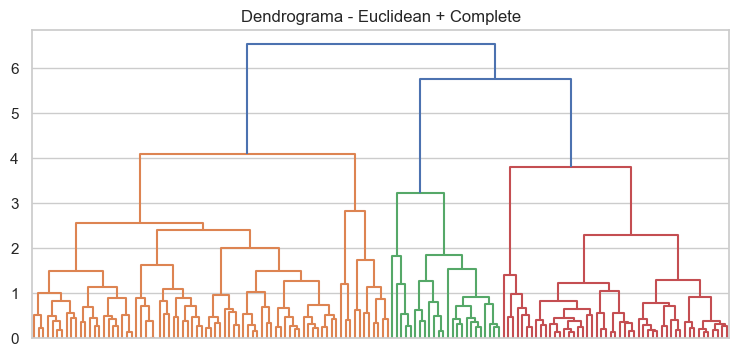

In [17]:
# Dendrograma complete
Z_complete = linkage(pdist(X, metric="euclidean"), method="complete")
plt.figure(figsize=(9, 4))
dendrogram(Z_complete, no_labels=True)
plt.title("Dendrograma - Euclidean + Complete")
plt.show()


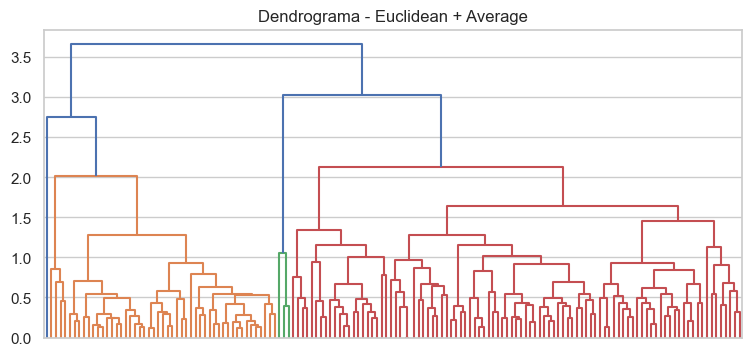

In [18]:
# Dendrograma average
Z_average = linkage(pdist(X, metric="euclidean"), method="average")
plt.figure(figsize=(9, 4))
dendrogram(Z_average, no_labels=True)
plt.title("Dendrograma - Euclidean + Average")
plt.show()


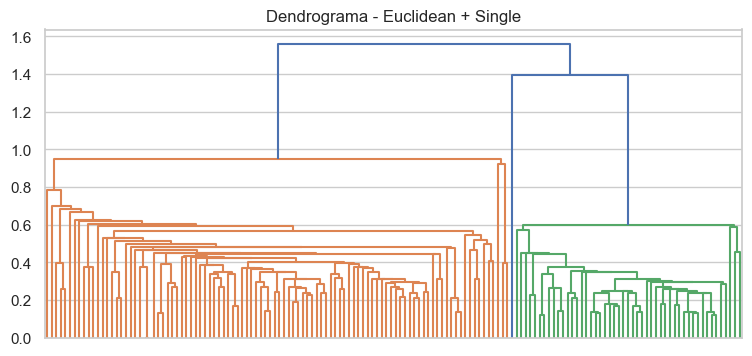

In [19]:
# Dendrograma single
Z_single = linkage(pdist(X, metric="euclidean"), method="single")
plt.figure(figsize=(9, 4))
dendrogram(Z_single, no_labels=True)
plt.title("Dendrograma - Euclidean + Single")
plt.show()


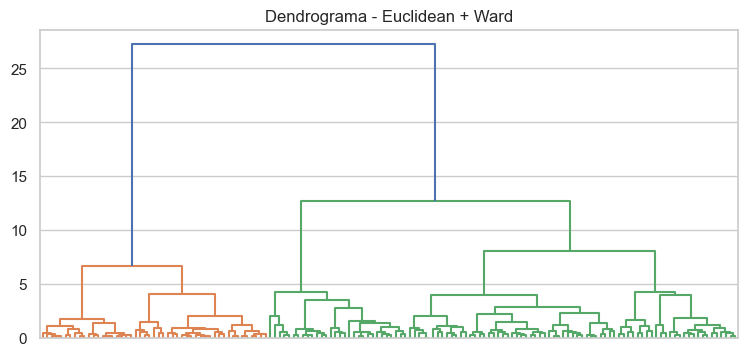

In [20]:
# Dendrograma ward
Z_ward = linkage(pdist(X, metric="euclidean"), method="ward")
plt.figure(figsize=(9, 4))
dendrogram(Z_ward, no_labels=True)
plt.title("Dendrograma - Euclidean + Ward")
plt.show()


## 5) Comparar distancias para metodos compatibles

In [21]:
# Distancias para complete, average, single
distancias = ["euclidean", "manhattan", "chebyshev", "minkowski"]
metodos_comp = ["complete", "average", "single"]
resultados = []
for distancia in distancias:
    for metodo in metodos_comp:
        modelo = AgglomerativeClustering(n_clusters=3, linkage=metodo, metric=distancia)
        labels = modelo.fit_predict(X)
        sil = silhouette_score(X, labels)
        resultados.append([distancia, metodo, "aglomerativo", sil])
pd.DataFrame(resultados, columns=["Distancia", "Metodo", "Tipo", "Silueta"]).sort_values("Silueta", ascending=False).head(12)


,Distancia,Metodo,Tipo,Silueta
2,euclidean,single,aglomerativo,0.504646
8,chebyshev,single,aglomerativo,0.504646
11,minkowski,single,aglomerativo,0.504646
5,manhattan,single,aglomerativo,0.494863
1,euclidean,average,aglomerativo,0.480267
10,minkowski,average,aglomerativo,0.480267
7,chebyshev,average,aglomerativo,0.474334
6,chebyshev,complete,aglomerativo,0.454040
4,manhattan,average,aglomerativo,0.452958
0,euclidean,complete,aglomerativo,0.449618


## 6) Visualizacion de silueta promedio

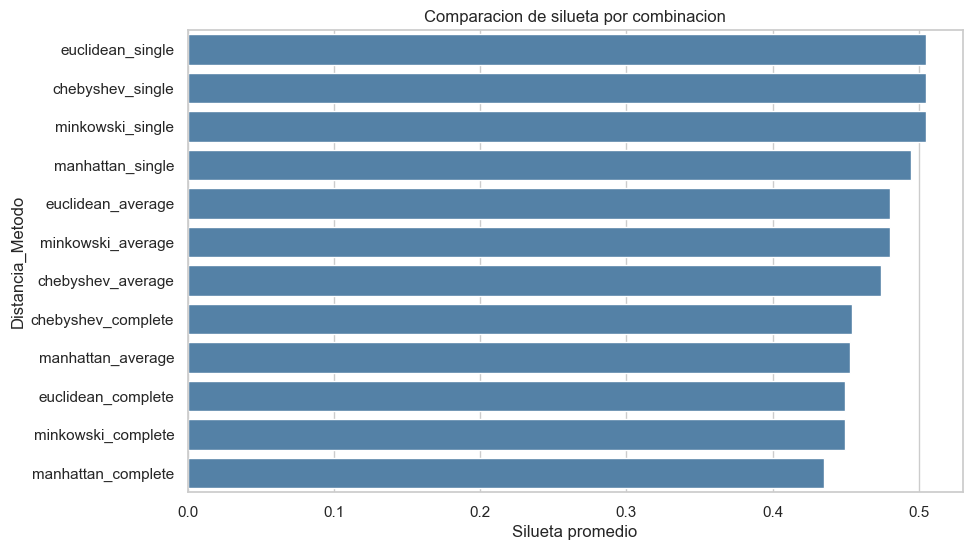

In [22]:
# Grafico resumen de silueta
tabla_sil = pd.DataFrame(resultados, columns=["Distancia", "Metodo", "Tipo", "Silueta"])
tabla_sil["Combinacion"] = tabla_sil["Distancia"] + "_" + tabla_sil["Metodo"]
tabla_sil = tabla_sil.sort_values("Silueta", ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(data=tabla_sil, y="Combinacion", x="Silueta", color="steelblue")
plt.title("Comparacion de silueta por combinacion")
plt.xlabel("Silueta promedio")
plt.ylabel("Distancia_Metodo")
plt.show()


## 7) Comparar mejor modelo contra variedad real

In [23]:
# Tomar mejor combinacion
mejor = tabla_sil.iloc[0]
modelo_final = AgglomerativeClustering(n_clusters=3, linkage=mejor["Metodo"], metric=mejor["Distancia"])
labels_final = modelo_final.fit_predict(X) + 1
tabla_final = pd.crosstab(pd.Series(labels_final, name="cluster"), iris_data["variety"])
tabla_final.index = [f"Cluster_{x}" for x in tabla_final.index]
tabla_final.columns = [f"Variety_{x}" for x in tabla_final.columns]
tabla_final


,Variety_Setosa,Variety_Versicolor,Variety_Virginica
Cluster_1,0,50,50
Cluster_2,1,0,0
Cluster_3,49,0,0


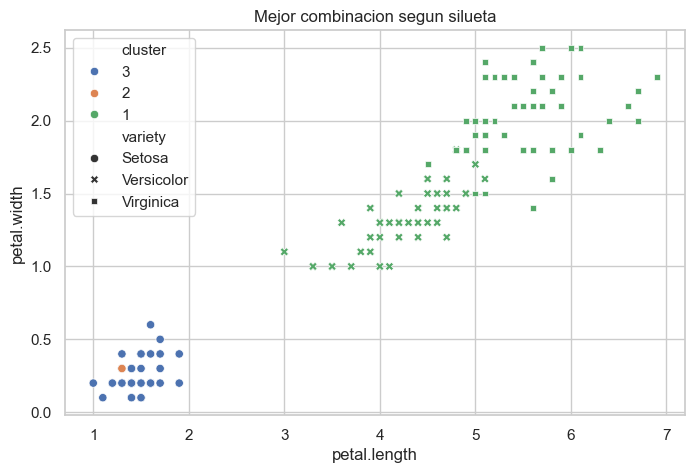

In [24]:
# Visualizacion del mejor modelo en 2D
plot_final = iris_numerico.copy()
plot_final["cluster"] = labels_final.astype(str)
plot_final["variety"] = iris_data["variety"].astype(str)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=plot_final, x="petal.length", y="petal.width", hue="cluster", style="variety")
plt.title("Mejor combinacion segun silueta")
plt.show()
